# Лабораторная работа: Продвинутая предобработка данных

В этом блокноте демонстрируются продвинутые методы предварительной обработки данных для машинного обучения.

### Описание набора данных
Для выполнения работы используется набор данных **California Housing**. Он содержит информацию о стоимости жилья в округах Калифорнии на основе переписи 1990 года.
- **Целевая переменная:** медианная стоимость дома.
- **Признаки:** включают средний доход, возраст дома, среднее количество комнат, количество спален, популяцию и географическое положение (широта и долгота).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, SequentialFeatureSelector, SelectFromModel
from sklearn.linear_model import Lasso, LinearRegression

# Загрузка набора данных
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print("Данные загружены. Размерность:", df.shape)
display(df.head())

Данные загружены. Размерность: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Масштабирование признаков (три способа)

Мы применим StandardScaler, MinMaxScaler и RobustScaler к признаку 'MedInc'.

In [2]:
col_to_scale = 'MedInc'

# 1. Standard Scaler (Стандартное масштабирование)
sc = StandardScaler()
df['MedInc_Standard'] = sc.fit_transform(df[[col_to_scale]])

# 2. Min-Max Scaler (Масштабирование по минимуму и максимуму)
mm = MinMaxScaler()
df['MedInc_MinMax'] = mm.fit_transform(df[[col_to_scale]])

# 3. Robust Scaler (Робастное масштабирование)
rs = RobustScaler()
df['MedInc_Robust'] = rs.fit_transform(df[[col_to_scale]])

display(df[[col_to_scale, 'MedInc_Standard', 'MedInc_MinMax', 'MedInc_Robust']].head())

,MedInc,MedInc_Standard,MedInc_MinMax,MedInc_Robust
0,8.3252,2.344766,0.539668,2.197582
1,8.3014,2.332238,0.538027,2.186664
2,7.2574,1.782699,0.466028,1.707732
3,5.6431,0.932968,0.354699,0.967177
4,3.8462,-0.012881,0.230776,0.142854


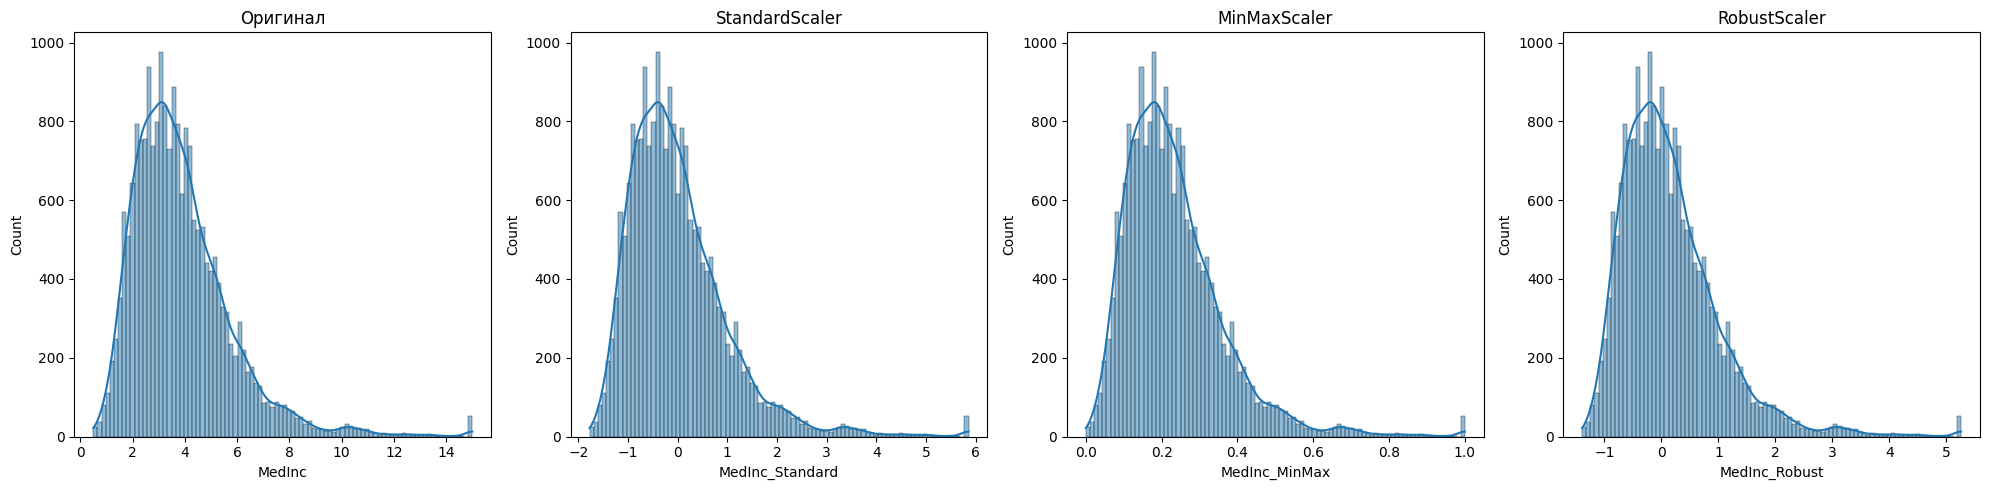

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.histplot(df[col_to_scale], ax=axes[0], kde=True).set_title('Оригинал')
sns.histplot(df['MedInc_Standard'], ax=axes[1], kde=True).set_title('StandardScaler')
sns.histplot(df['MedInc_MinMax'], ax=axes[2], kde=True).set_title('MinMaxScaler')
sns.histplot(df['MedInc_Robust'], ax=axes[3], kde=True).set_title('RobustScaler')
plt.tight_layout()
plt.show()

## 2. Обработка выбросов

Мы обработаем выбросы для признака 'AveRooms'.

In [4]:
# Способ 1: Удаление выбросов с использованием межквартильного размаха (IQR)
Q1 = df['AveRooms'].quantile(0.25)
Q3 = df['AveRooms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['AveRooms'] >= lower_bound) & (df['AveRooms'] <= upper_bound)]

# Способ 2: Замена выбросов (Винзоризация — ограничение по границам)
df['AveRooms_Capped'] = df['AveRooms'].clip(lower=lower_bound, upper=upper_bound)

print(f"Исходный размер: {len(df)}, Размер после удаления выбросов: {len(df_no_outliers)}")

Исходный размер: 20640, Размер после удаления выбросов: 20129


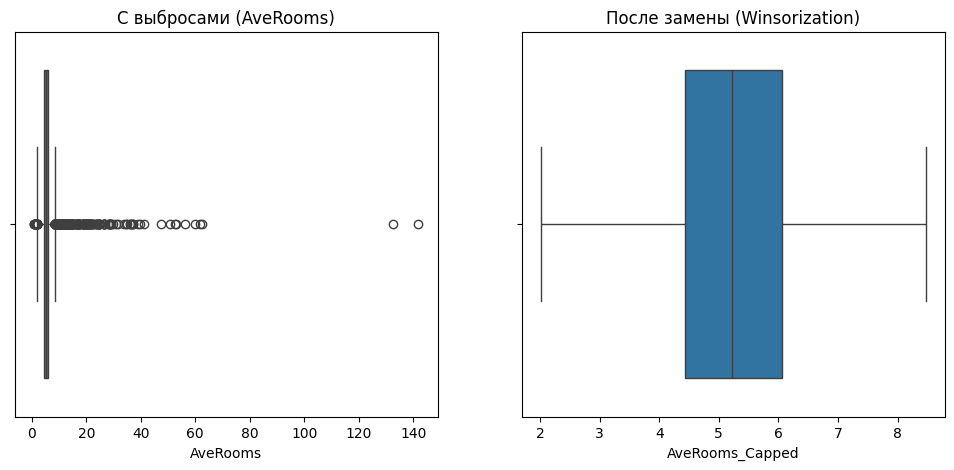

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['AveRooms'], ax=axes[0]).set_title('С выбросами (AveRooms)')
sns.boxplot(x=df['AveRooms_Capped'], ax=axes[1]).set_title('После замены (Winsorization)')
plt.show()

## 3. Обработка нестандартного признака

Создадим фиктивный признак 'timestamp' для демонстрации обработки даты и времени.

In [6]:
# Создание фиктивного столбца с датами
df['date_recorded'] = pd.date_range(start='2020-01-01', periods=len(df), freq='H')

# Извлечение компонентов даты
df['hour'] = df['date_recorded'].dt.hour
df['day_of_week'] = df['date_recorded'].dt.dayofweek

display(df[['date_recorded', 'hour', 'day_of_week']].head())

/tmp/ipykernel_1703/4066759905.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['date_recorded'] = pd.date_range(start='2020-01-01', periods=len(df), freq='H')


,date_recorded,hour,day_of_week
0,2020-01-01 00:00:00,0,2
1,2020-01-01 01:00:00,1,2
2,2020-01-01 02:00:00,2,2
3,2020-01-01 03:00:00,3,2
4,2020-01-01 04:00:00,4,2


## 4. Отбор признаков

In [7]:
X = df[data.feature_names]
y = df['Target']

# 1. Метод фильтрации (Filter Method): SelectKBest (используя F-регрессию)
filter_sel = SelectKBest(score_func=f_regression, k=4)
X_filter = filter_sel.fit_transform(X, y)
print("Признаки, отобранные методом фильтрации:", X.columns[filter_sel.get_support()].tolist())

# 2. Метод обертки (Wrapper Method): Последовательный отбор признаков
wrapper_sel = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3, direction='forward')
wrapper_sel.fit(X, y)
print("Признаки, отобранные методом обертки:", X.columns[wrapper_sel.get_support()].tolist())

# 3. Метод вложений (Embedded Method): Lasso (L1-регуляризация)
embedded_sel = SelectFromModel(Lasso(alpha=0.01))
embedded_sel.fit(X, y)
print("Признаки, отобранные методом вложений:", X.columns[embedded_sel.get_support()].tolist())

Признаки, отобранные методом фильтрации: ['MedInc', 'HouseAge', 'AveRooms', 'Latitude']
Признаки, отобранные методом обертки: ['MedInc', 'HouseAge', 'AveRooms']
Признаки, отобранные методом вложений: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']


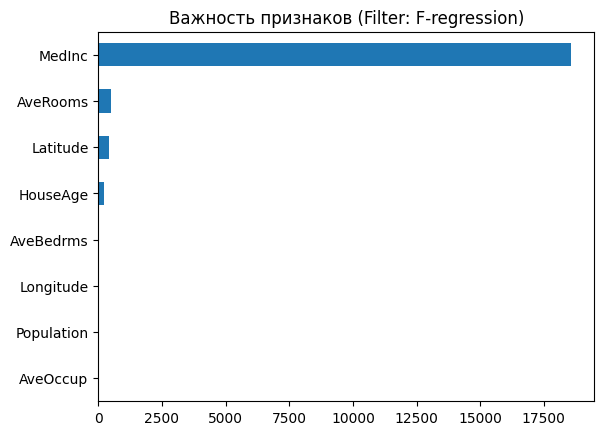

In [8]:
# Визуализация результатов метода фильтрации (F-scores)
f_scores = pd.Series(filter_sel.scores_, index=X.columns)
f_scores.sort_values().plot(kind='barh', title='Важность признаков (Filter: F-regression)')
plt.show()

### Интерпретация результатов

1. **Масштабирование:**
   - `StandardScaler` центрировал данные около нуля с единичным отклонением.
   - `MinMaxScaler` сжал данные строго в диапазон [0, 1].
   - `RobustScaler` сохранил структуру распределения, минимизировав влияние экстремальных значений (выбросов) за счет использования медианы и межквартильного размаха.

2. **Обработка выбросов:**
   - Использование метода IQR позволило выявить экстремально большие значения комнат (`AveRooms`).
   - Метод замены (винзоризация) «подтянул» значения за пределами границ к максимально допустимым, сохранив размер выборки, но избавившись от аномалий.

3. **Отбор признаков:**
   - **Filter Method** показал, что доход (`MedInc`) имеет самую сильную линейную связь с ценой.
   - **Wrapper Method** отобрал наиболее компактную и эффективную комбинацию признаков.
   - **Embedded Method (Lasso)** автоматически обнулил веса наименее значимых признаков, оставив те, что наиболее важны для регуляризованной модели.